In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [ ]:
list_AC_stark_vals=[np.float64(-0.06854670085959402), np.float64(-0.07915537484610222), np.float64(-0.09052059521492348), np.float64(-0.10284236196605781), np.float64(-0.11592067509950522), np.float64(-0.12985553461526572), np.float64(-0.14474694051333922), np.float64(-0.1603948927937259), np.float64(-0.17729939145642556), np.float64(-0.19496043650143846), np.float64(-0.21367802792876428), np.float64(-0.23345216573840316), np.float64(-0.25428284993035516), np.float64(-0.2759700805046203), np.float64(-0.29891385746119853), np.float64(-0.32291418080008977), np.float64(-0.3477710505212941), np.float64(-0.37378446662481146), np.float64(-0.400954429110642), np.float64(-0.42888093797878557)]
list_ef_AC_stark_vals=[np.float64(5.862378319584177), np.float64(6.291660027196749), np.float64(6.720941734809321), np.float64(7.1502234424218925), np.float64(7.579505150034464), np.float64(8.008786857647035), np.float64(8.438068565259606), np.float64(8.867350272872178), np.float64(9.296631980484749), np.float64(9.725913688097322), np.float64(10.155195395709892), np.float64(10.584477103322463), np.float64(11.013758810935034), np.float64(11.443040518547605), np.float64(11.872322226160177), np.float64(12.30160393377275), np.float64(12.73088564138532), np.float64(13.160167348997891), np.float64(13.589449056610464), np.float64(14.018730764223035)]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,f_supp,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_supp,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_supp,A,evolution,dim,f_rabi,t_ramp=5,U_f=2,drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q/3 (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

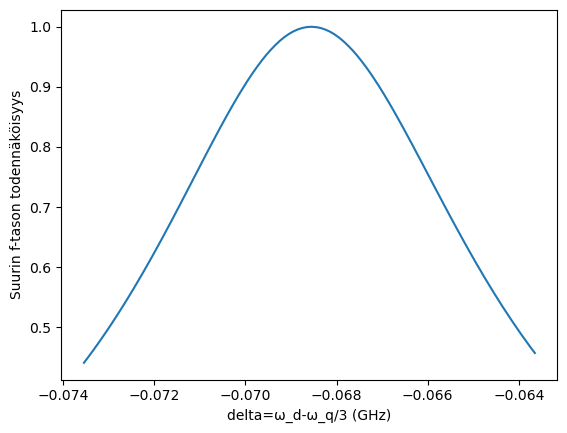

Amplitudi (GHz): 5.862378319586982
AC-stark siirtymä (GHz): -0.06854670085959402
E-tason suurin todennäköisyys: 0.9999933907983507
Pulssin pituus (ns): 241.11858889321533
Rabi-taajuus (fourier):  0.002185167692923797


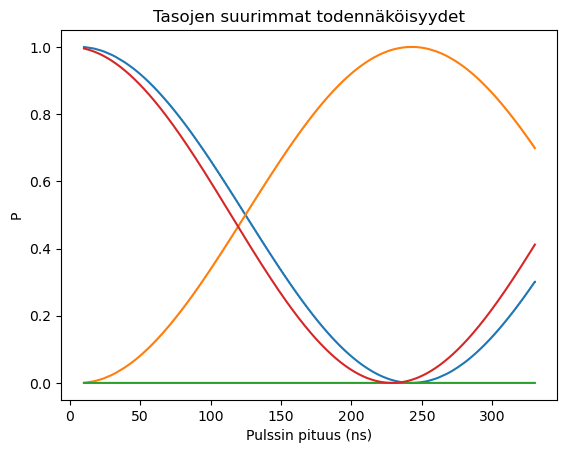

---------------------------------------------


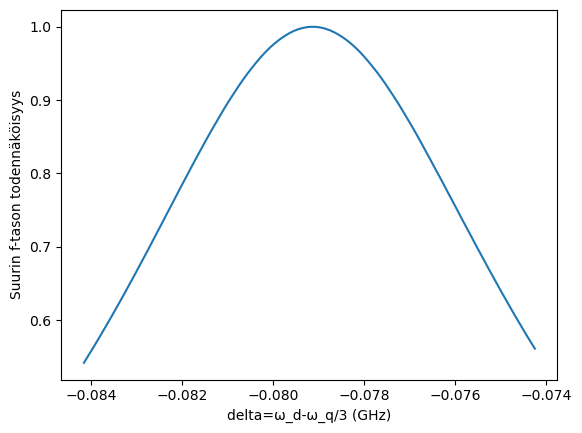

Amplitudi (GHz): 6.291660027199759
AC-stark siirtymä (GHz): -0.07915537484610222
E-tason suurin todennäköisyys: 0.9999901363292433
Pulssin pituus (ns): 196.62087589075497


Rabi-taajuus (fourier):  0.0024583838483573017


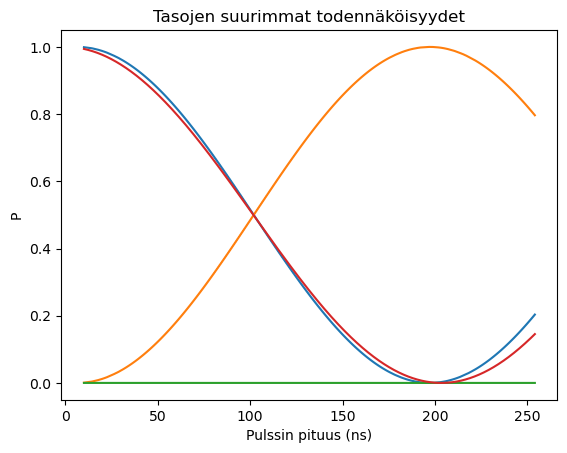

---------------------------------------------


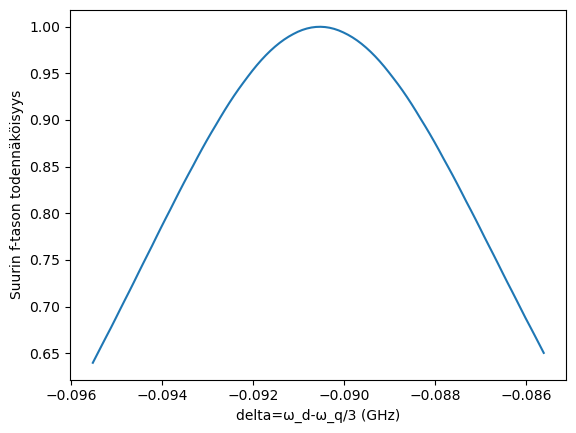

Amplitudi (GHz): 6.720941734812535
AC-stark siirtymä (GHz): -0.09052059521492348
E-tason suurin todennäköisyys: 0.9999911743939882
Pulssin pituus (ns): 163.23602709190993
Rabi-taajuus (fourier):  0.0030942054261310584


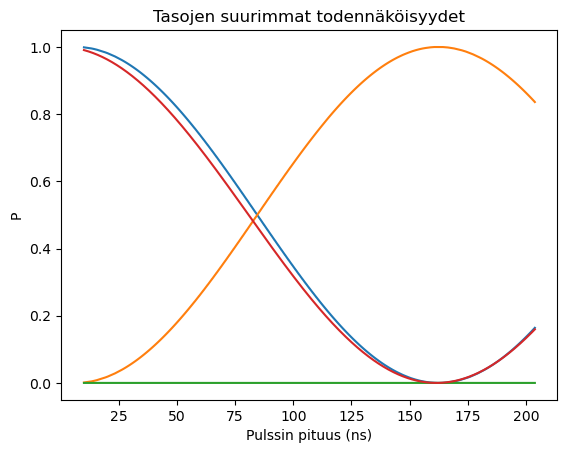

---------------------------------------------


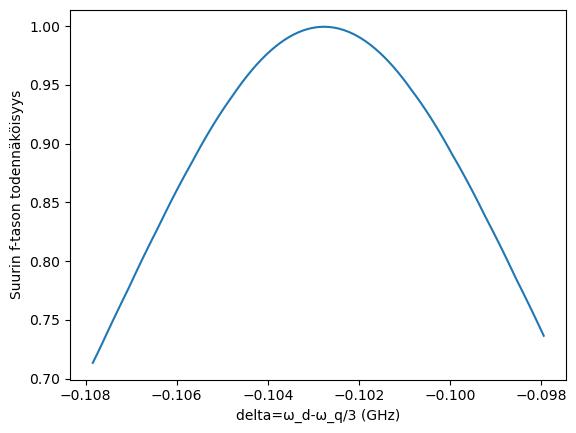

Amplitudi (GHz): 7.150223442425313
AC-stark siirtymä (GHz): -0.10274236196605781
E-tason suurin todennäköisyys: 0.999987491889821
Pulssin pituus (ns): 133.51590526626714
Rabi-taajuus (fourier):  0.003793351512646916


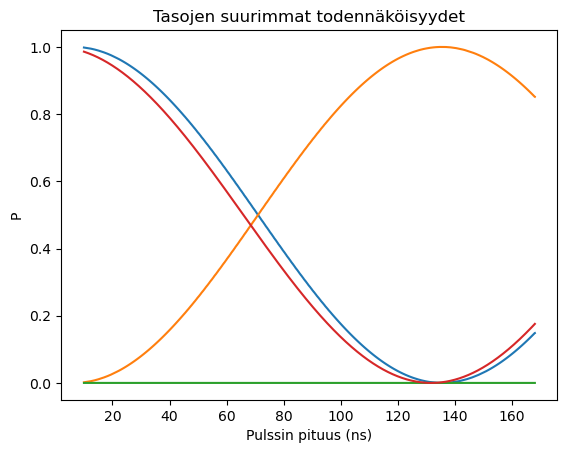

---------------------------------------------


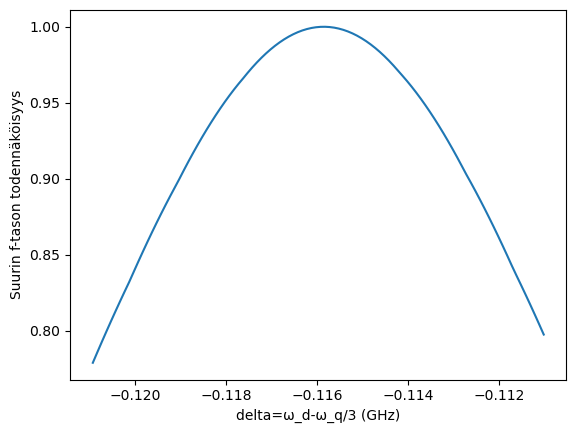

Amplitudi (GHz): 7.57950515003809
AC-stark siirtymä (GHz): -0.11582067509950522
E-tason suurin todennäköisyys: 0.9999874338172583
Pulssin pituus (ns): 114.96492584469384
Rabi-taajuus (fourier):  0.0045690397999157036


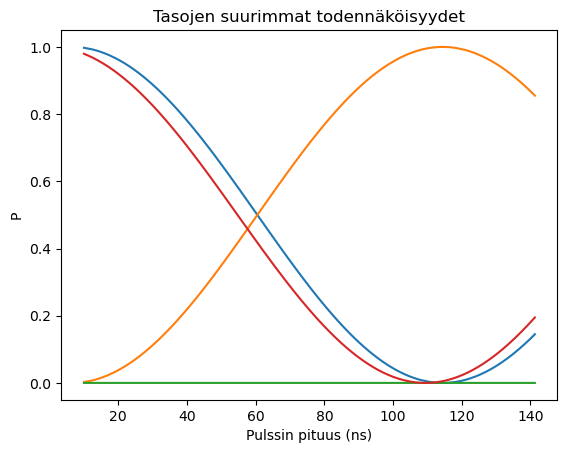

---------------------------------------------


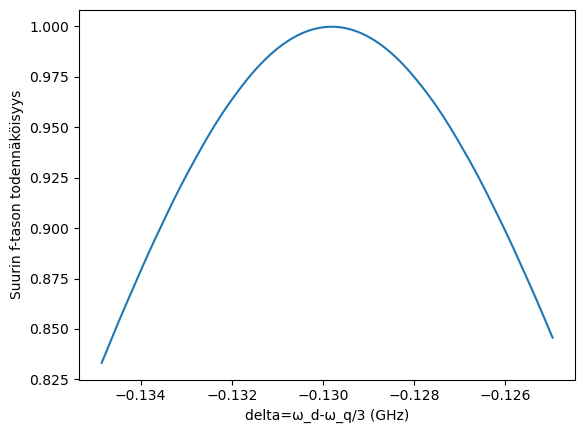

Amplitudi (GHz): 8.008786857650867
AC-stark siirtymä (GHz): -0.12985553461526572
E-tason suurin todennäköisyys: 0.9999778336412954
Pulssin pituus (ns): 97.1168355903274
Rabi-taajuus (fourier):  0.005434138828694903


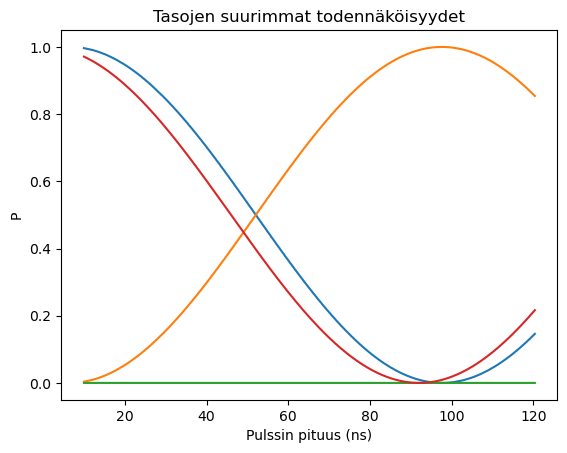

---------------------------------------------


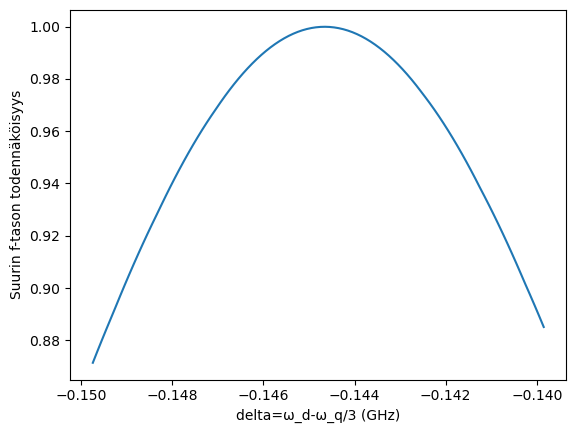

Amplitudi (GHz): 8.438068565263642
AC-stark siirtymä (GHz): -0.14464694051333923
E-tason suurin todennäköisyys: 0.9999829949844732
Pulssin pituus (ns): 83.72905632864345
Rabi-taajuus (fourier):  0.006401883326320411


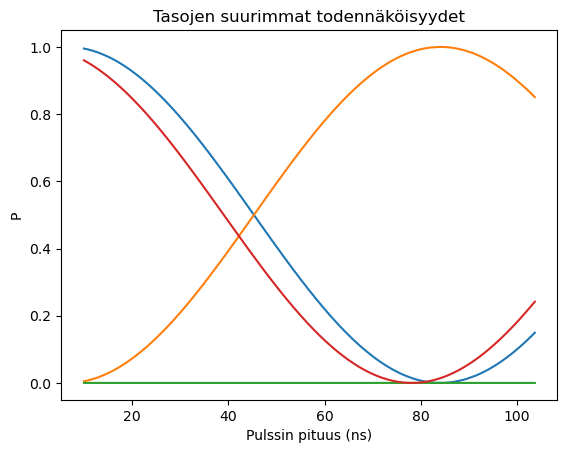

---------------------------------------------


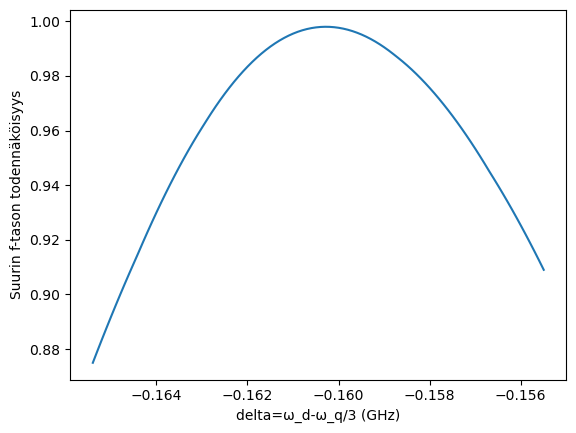

Amplitudi (GHz): 8.86735027287642
AC-stark siirtymä (GHz): -0.1602948927937259
E-tason suurin todennäköisyys: 0.9979859515280416
Pulssin pituus (ns): 73.31496456470664
Rabi-taajuus (fourier):  0.007484911575021421


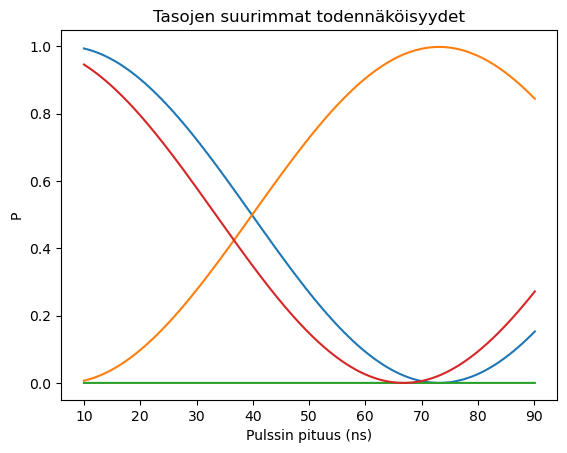

---------------------------------------------


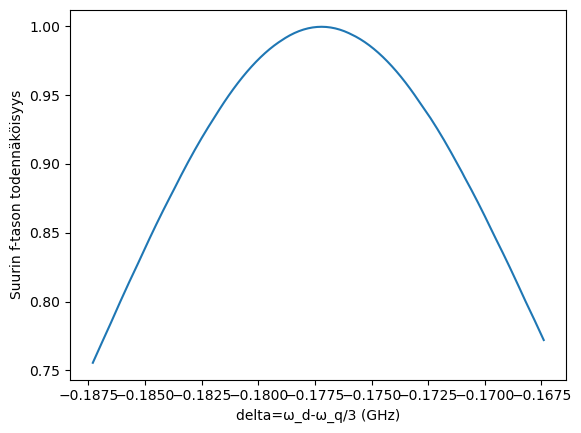

Amplitudi (GHz): 9.296631980489197
AC-stark siirtymä (GHz): -0.17719939145642558
E-tason suurin todennäköisyys: 0.9998043920904361
Pulssin pituus (ns): 64.38024808713851
Rabi-taajuus (fourier):  0.008696765945480987


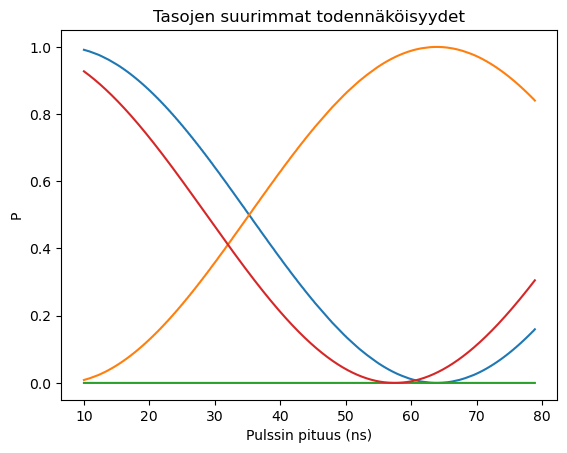

---------------------------------------------


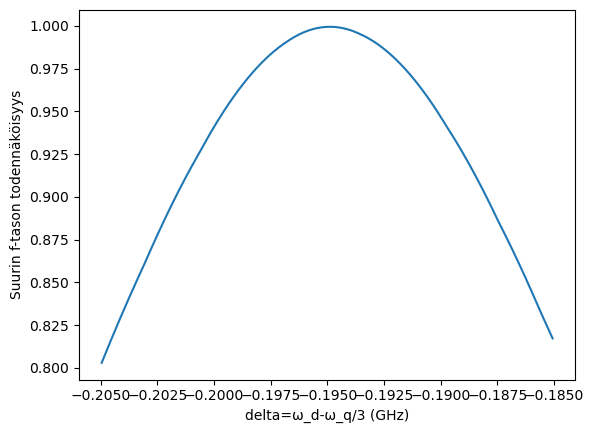

Amplitudi (GHz): 9.725913688101974
AC-stark siirtymä (GHz): -0.19486043650143847
E-tason suurin todennäköisyys: 0.9999092905005111
Pulssin pituus (ns): 56.92706090747744
Rabi-taajuus (fourier):  0.010050327476621478


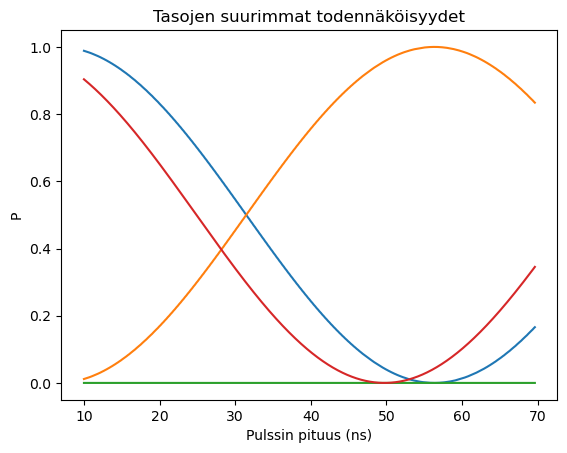

---------------------------------------------


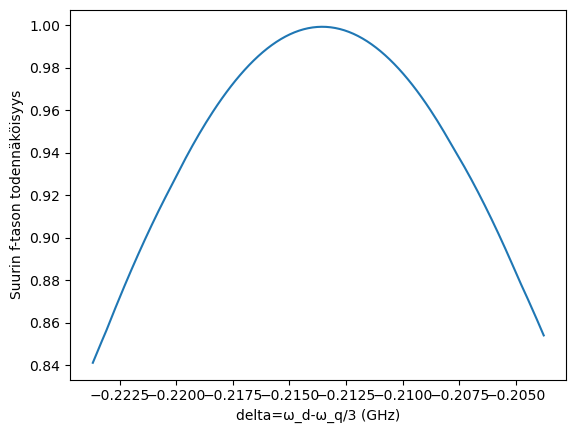

Amplitudi (GHz): 10.15519539571475
AC-stark siirtymä (GHz): -0.2135780279287643
E-tason suurin todennäköisyys: 0.9999292826408671
Pulssin pituus (ns): 49.447124208293175
Rabi-taajuus (fourier):  0.011558266570209351


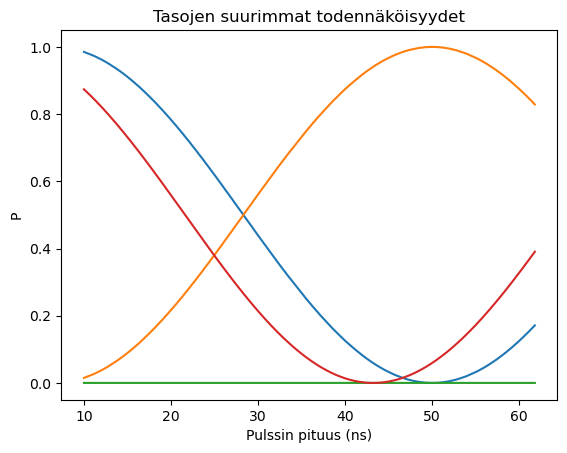

---------------------------------------------


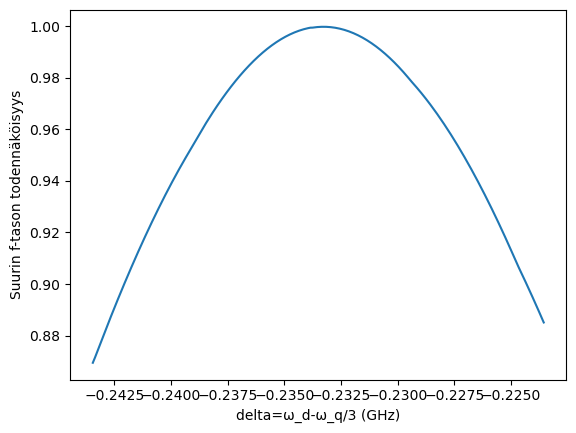

Amplitudi (GHz): 10.584477103327528
AC-stark siirtymä (GHz): -0.23325216573840316
E-tason suurin todennäköisyys: 0.9999515834745051
Pulssin pituus (ns): 44.97861946202862
Rabi-taajuus (fourier):  0.013233600664643016


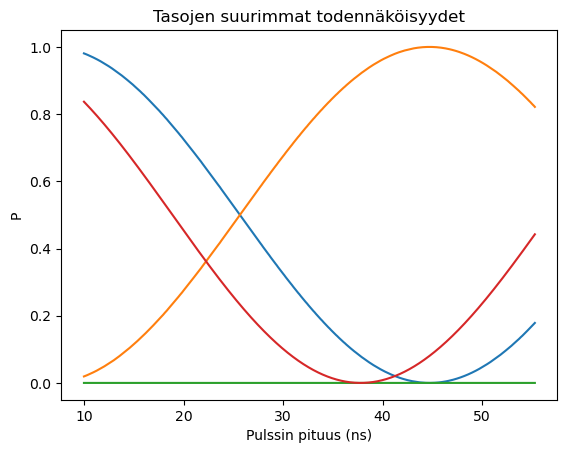

---------------------------------------------


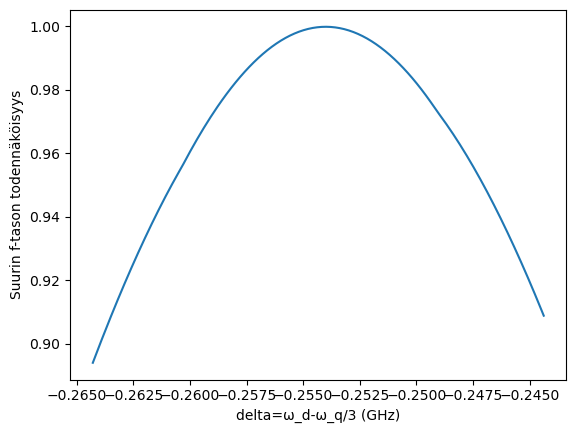

Amplitudi (GHz): 11.013758810940303
AC-stark siirtymä (GHz): -0.25398284993035514
E-tason suurin todennäköisyys: 0.9999630901991706
Pulssin pituus (ns): 40.49269311738203
Rabi-taajuus (fourier):  0.015091051770906905


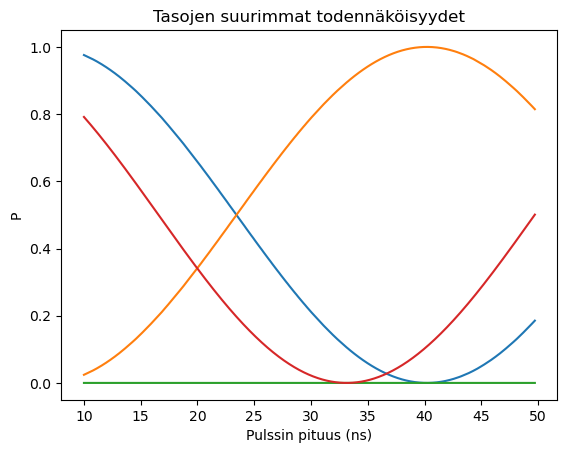

---------------------------------------------


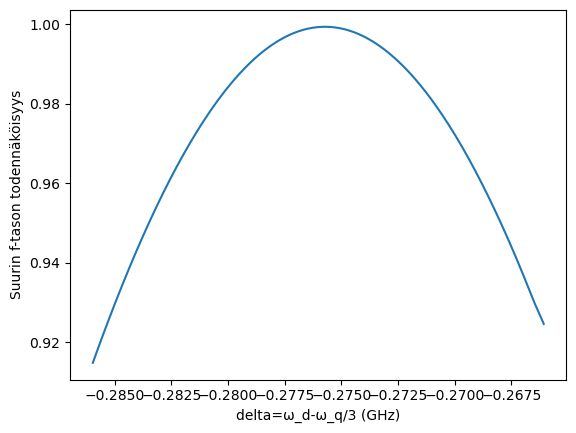

Amplitudi (GHz): 11.44304051855308
AC-stark siirtymä (GHz): -0.2757700805046203
E-tason suurin todennäköisyys: 0.9999703103329538
Pulssin pituus (ns): 35.9874836838958
Rabi-taajuus (fourier):  0.017141462558059827


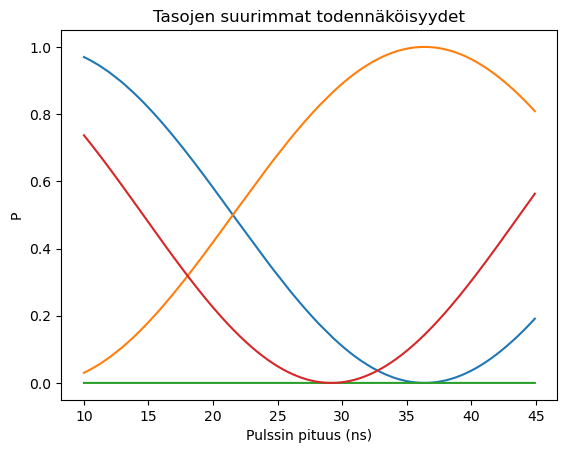

---------------------------------------------


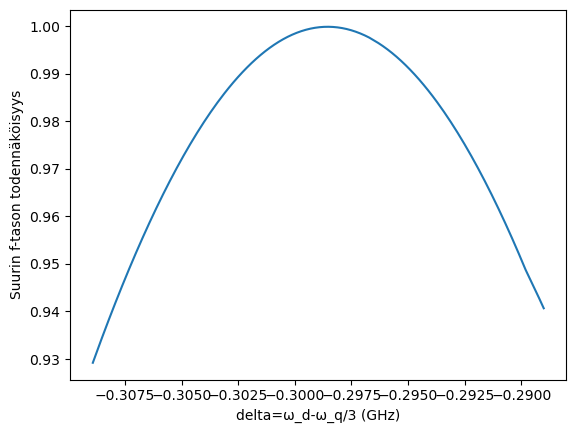

Amplitudi (GHz): 11.872322226165856
AC-stark siirtymä (GHz): -0.2985138574611985
E-tason suurin todennäköisyys: 0.9999622163985501
Pulssin pituus (ns): 32.99375034465595
Rabi-taajuus (fourier):  0.019398374603643433


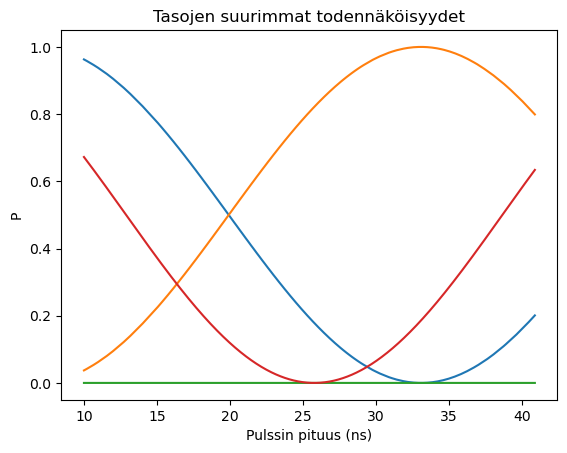

---------------------------------------------


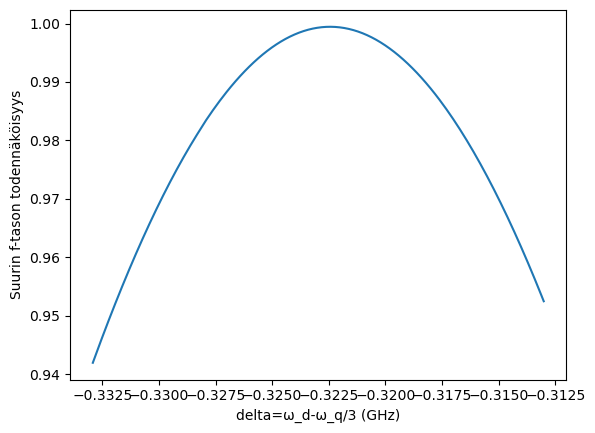

Amplitudi (GHz): 12.301603933778635
AC-stark siirtymä (GHz): -0.32241418080008977
E-tason suurin todennäköisyys: 0.9999092678393763
Pulssin pituus (ns): 29.98618661452364
Rabi-taajuus (fourier):  0.021876095694212398


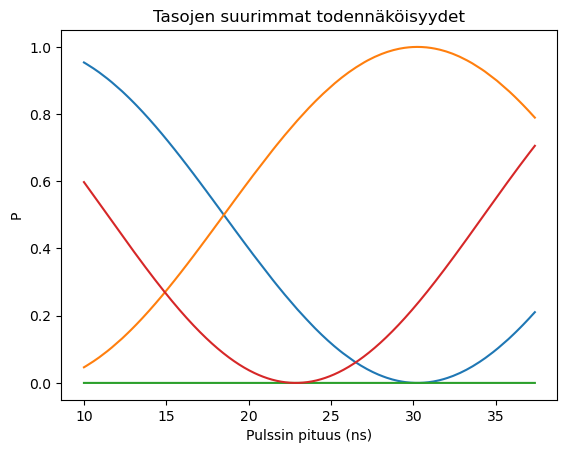

---------------------------------------------


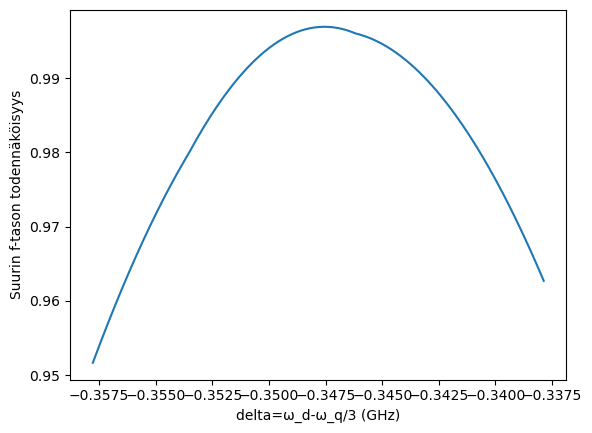

Amplitudi (GHz): 12.730885641391412
AC-stark siirtymä (GHz): -0.3475710505212941
E-tason suurin todennäköisyys: 0.9999200994697475
Pulssin pituus (ns): 28.505743694546336
Rabi-taajuus (fourier):  0.024585680577194416


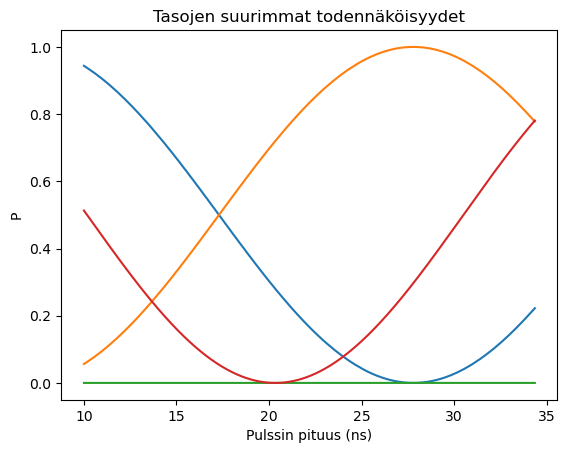

---------------------------------------------


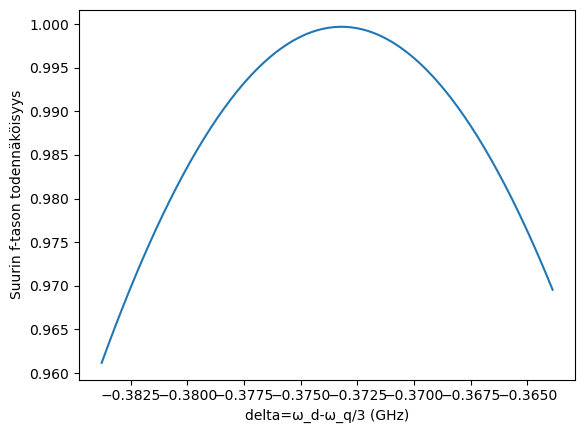

Amplitudi (GHz): 13.160167349004187
AC-stark siirtymä (GHz): -0.3731844666248115
E-tason suurin todennäköisyys: 0.9999241413684252
Pulssin pituus (ns): 25.470079856674552
Rabi-taajuus (fourier):  0.02754095115209619


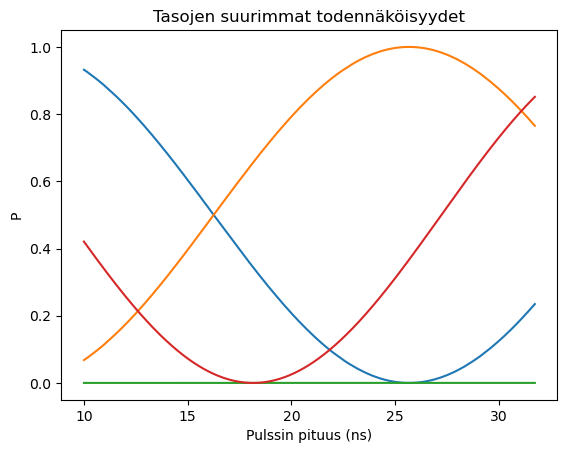

---------------------------------------------


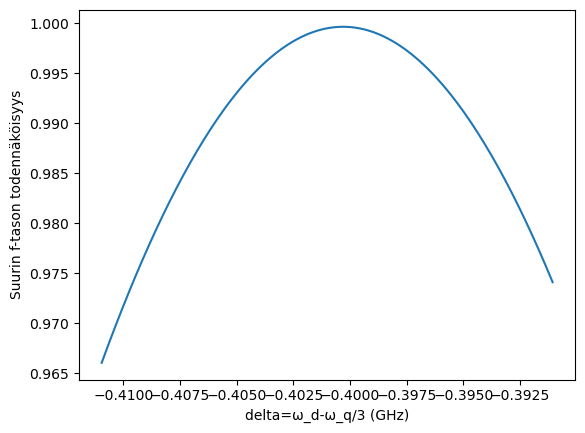

Amplitudi (GHz): 13.589449056616964
AC-stark siirtymä (GHz): -0.400254429110642
E-tason suurin todennäköisyys: 0.9998834647175219
Pulssin pituus (ns): 23.969625668630016
Rabi-taajuus (fourier):  0.030758141961225827


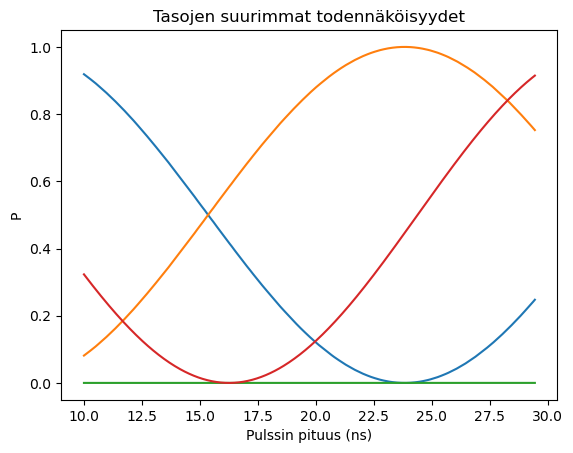

---------------------------------------------


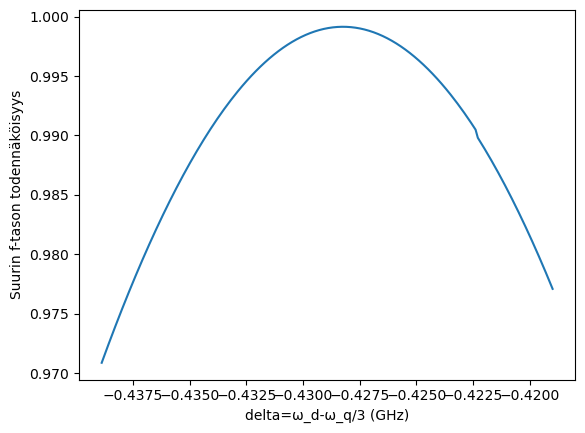

Amplitudi (GHz): 14.01873076422974
AC-stark siirtymä (GHz): -0.4282809379787856
E-tason suurin todennäköisyys: 0.9998088417243038
Pulssin pituus (ns): 22.460581021040426
Rabi-taajuus (fourier):  0.034241313944046364


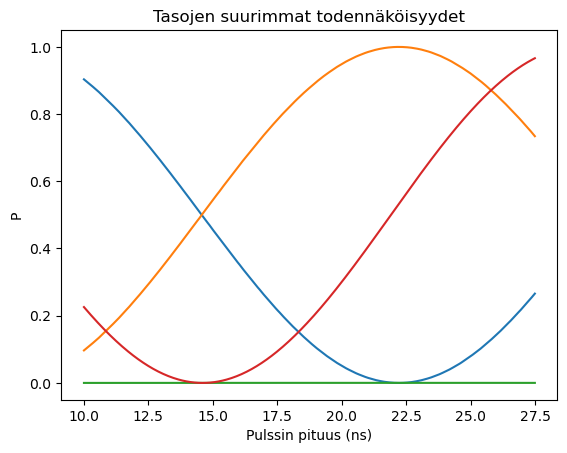

---------------------------------------------


In [ ]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.55
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d = qubit.frequency/3 #Optimaalinen ajotaajuus
    f_supp_opt = f_ef/3

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=list_AC_stark_vals[i] #Arvaus AC-stark siirtymälle

    if i < 8:
        params=find_params(f_d,f_supp_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-50,50],10000)
    else:
        params=find_params(f_d,f_supp_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-100,100],10000)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    m=10

    vals = pulses.sim_3_part_pulses(f_d+deltas[-1],f_supp_opt,A,evolution_eigenbasis,dim,(10*f_rabi)/m,t_ramp=5,U_f=0,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319586982), np.float64(6.291660027199759), np.float64(6.720941734812535), np.float64(7.150223442425313), np.float64(7.57950515003809), np.float64(8.008786857650867), np.float64(8.438068565263642), np.float64(8.86735027287642), np.float64(9.296631980489197), np.float64(9.725913688101974), np.float64(10.15519539571475), np.float64(10.584477103327528), np.float64(11.013758810940303), np.float64(11.44304051855308), np.float64(11.872322226165856), np.float64(12.301603933778635), np.float64(12.730885641391412), np.float64(13.160167349004187), np.float64(13.589449056616964), np.float64(14.01873076422974)]


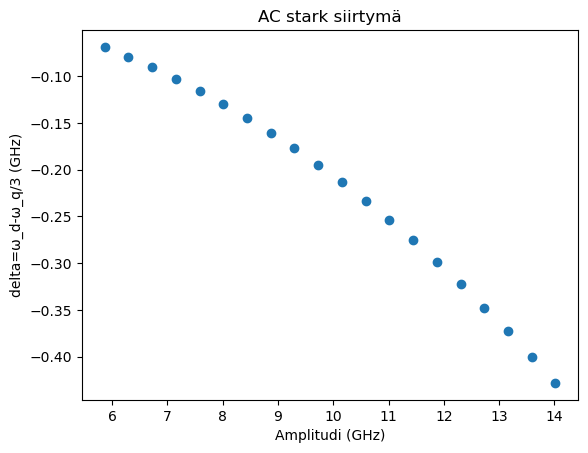

[np.float64(-0.06854670085959402), np.float64(-0.07915537484610222), np.float64(-0.09052059521492348), np.float64(-0.10274236196605781), np.float64(-0.11582067509950522), np.float64(-0.12985553461526572), np.float64(-0.14464694051333923), np.float64(-0.1602948927937259), np.float64(-0.17719939145642558), np.float64(-0.19486043650143847), np.float64(-0.2135780279287643), np.float64(-0.23325216573840316), np.float64(-0.25398284993035514), np.float64(-0.2757700805046203), np.float64(-0.2985138574611985), np.float64(-0.32241418080008977), np.float64(-0.3475710505212941), np.float64(-0.3731844666248115), np.float64(-0.400254429110642), np.float64(-0.4282809379787856)]


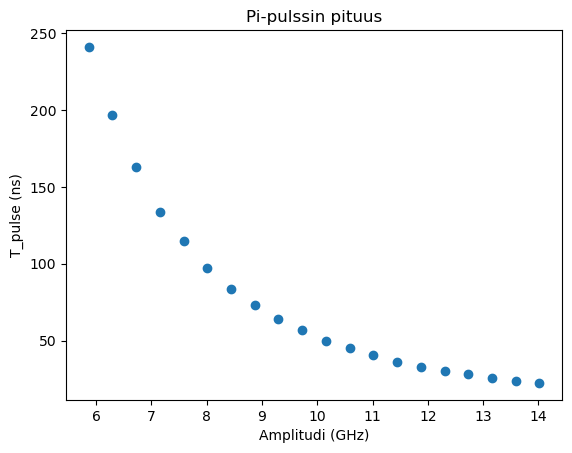

[np.float64(241.11858889321533), np.float64(196.62087589075497), np.float64(163.23602709190993), np.float64(133.51590526626714), np.float64(114.96492584469384), np.float64(97.1168355903274), np.float64(83.72905632864345), np.float64(73.31496456470664), np.float64(64.38024808713851), np.float64(56.92706090747744), np.float64(49.447124208293175), np.float64(44.97861946202862), np.float64(40.49269311738203), np.float64(35.9874836838958), np.float64(32.99375034465595), np.float64(29.98618661452364), np.float64(28.505743694546336), np.float64(25.470079856674552), np.float64(23.969625668630016), np.float64(22.460581021040426)]


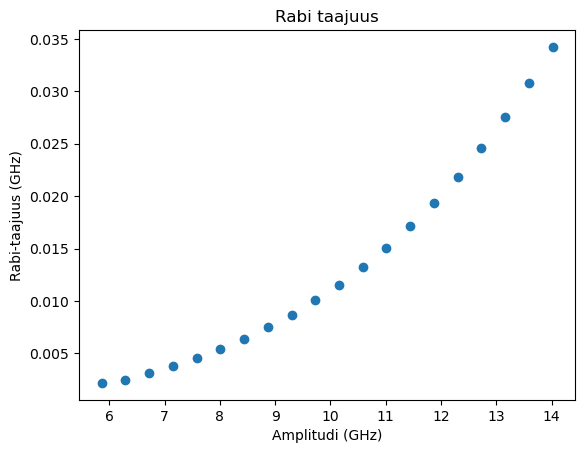

[np.float64(0.002185167692923797), np.float64(0.0024583838483573017), np.float64(0.0030942054261310584), np.float64(0.003793351512646916), np.float64(0.0045690397999157036), np.float64(0.005434138828694903), np.float64(0.006401883326320411), np.float64(0.007484911575021421), np.float64(0.008696765945480987), np.float64(0.010050327476621478), np.float64(0.011558266570209351), np.float64(0.013233600664643016), np.float64(0.015091051770906905), np.float64(0.017141462558059827), np.float64(0.019398374603643433), np.float64(0.021876095694212398), np.float64(0.024585680577194416), np.float64(0.02754095115209619), np.float64(0.030758141961225827), np.float64(0.034241313944046364)]


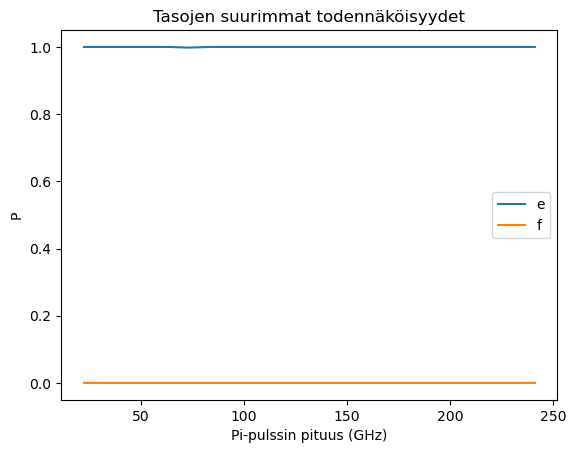

[np.float64(0.9999933907983507), np.float64(0.9999901363292433), np.float64(0.9999911743939882), np.float64(0.999987491889821), np.float64(0.9999874338172583), np.float64(0.9999778336412954), np.float64(0.9999829949844732), np.float64(0.9979859515280416), np.float64(0.9998043920904361), np.float64(0.9999092905005111), np.float64(0.9999292826408671), np.float64(0.9999515834745051), np.float64(0.9999630901991706), np.float64(0.9999703103329538), np.float64(0.9999622163985501), np.float64(0.9999092678393763), np.float64(0.9999200994697475), np.float64(0.9999241413684252), np.float64(0.9998834647175219), np.float64(0.9998088417243038)]
[np.float64(2.1153364609918955e-06), np.float64(2.7698123586891975e-06), np.float64(3.3252712667010264e-06), np.float64(3.8209630125803315e-06), np.float64(4.4463906407911316e-06), np.float64(4.926585210867477e-06), np.float64(5.67591171201363e-06), np.float64(3.401140284462302e-05), np.float64(1.1163989287667894e-06), np.float64(1.3998970402814078e-06), np.

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)